## Task 3: Scikit-learn wrapper for a PyTorch model

#### Goal: Implement a scikit-learn-compatible wrapper for a PyTorch model and use it with scikit-learn calibration methods.

1. Implement `MyWrapper` as a subclass of `ClassifierMixin` and `BaseEstimator`. The constructor must accept at minimum: `model`, `classes`, `lr`, `epochs`, `batch_size`, `device`, and `is_fitted`. The wrapper must support both pre-trained and untrained PyTorch models (controlled by the `is_fitted` flag).
2. Implement the `fit`, `predict`, `predict_proba`, and `score` methods so that the wrapper integrates with standard scikit-learn utilities such as `cross_val_score` and `confusion_matrix`.
3. Wrap a trained model with `is_fitted=True` and verify it works with `cross_val_score`, `confusion_matrix`, and `accuracy_score`.
4. Use `CalibratedClassifierCV` with `FrozenEstimator` to calibrate the wrapped model using all three available methods: `sigmoid`, `isotonic`, and `temperature` (available from scikit-learn 1.8.0). For each method, compute calibration curves and Brier score on the validation set.

**Assignment:** Calibrate a trained PyTorch model using scikit-learn infrastructure. Compare calibration quality across all three methods using Brier score.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from utils import *

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=5000, n_features=20)
X, y = torch.tensor(X, dtype=torch.float), torch.tensor(y)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2)

model = MLP(input_size=20, hidden_layers=[64, 256, 64], output_size=2)

fold_models = []
fold_models = fold_train(X_trainval=X_trainval, y_trainval=y_trainval,
                         model=model, EPOCHS=2, device=device)

ensemble = [load_model(k, model, device) for k in fold_models]

scalers = []
for i, m in enumerate(ensemble):
    print(f"Fitting scaler for model {i+1}/5...")
    s = fit_temperature(m, X_test, y_test)
    scalers.append(s)

Fold 1/5 — best val loss: 0.5771
Fold 2/5 — best val loss: 0.5700
Fold 3/5 — best val loss: 0.5644
Fold 4/5 — best val loss: 0.5700
Fold 5/5 — best val loss: 0.5617
Fitting scaler for model 1/5...
  Fitted T = 2.0506
Fitting scaler for model 2/5...
  Fitted T = 2.0655
Fitting scaler for model 3/5...
  Fitted T = 2.0625
Fitting scaler for model 4/5...
  Fitted T = 2.0672
Fitting scaler for model 5/5...
  Fitted T = 2.0560


In [4]:
import sklearn
print(sklearn.__version__)

1.8.0


In [5]:
import copy
import numpy as np

base_model = copy.deepcopy(model)
base_model.load_state_dict(fold_models[0]['model_state'])

clf = MyWrapper(model=base_model, classes=np.unique(y_train.numpy()),
                device=device, is_fitted=True)
clf.fit(X_test.numpy(), y_test.numpy())

,model,MLP( (input...ion): ReLU() )
,classes,"array([0, 1])"
,batch_size,256
,lr,0.001
,epochs,10
,device,'mps'
,is_fitted,True


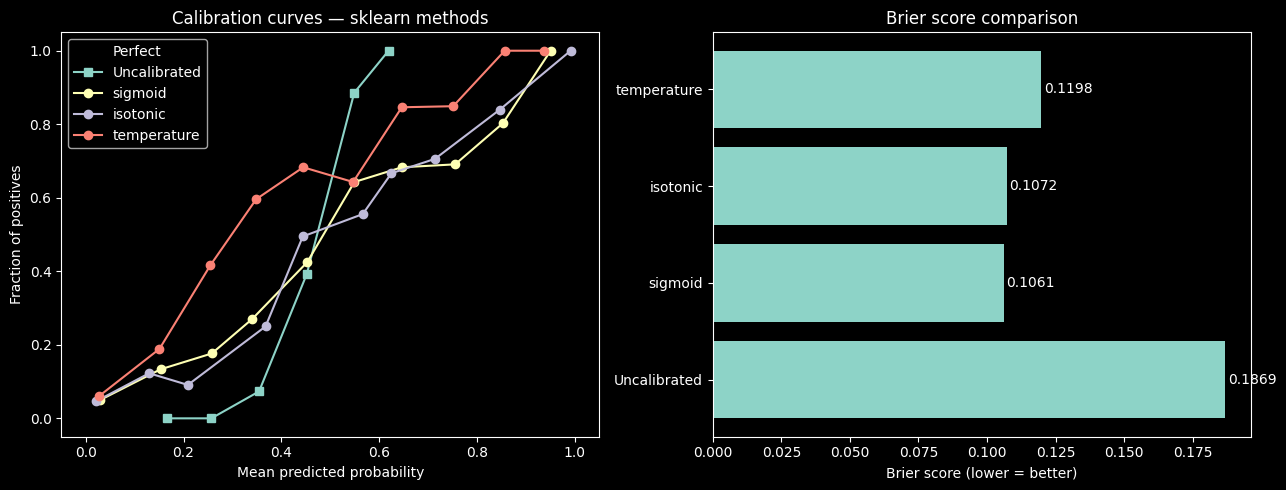


Brier scores:
  Uncalibrated   : 0.1869
  sigmoid        : 0.1061
  isotonic       : 0.1072
  temperature    : 0.1198


In [10]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

methods = ['sigmoid', 'isotonic', 'temperature']
calibrated_clfs = {}

n_samples = len(X_test)
cv_prefit = [(np.arange(n_samples), np.arange(n_samples))]

for method in methods:
    cal_clf = CalibratedClassifierCV(FrozenEstimator(clf), method=method, cv=cv_prefit)
    cal_clf.fit(X_test.numpy(), y_test.numpy())
    calibrated_clfs[method] = cal_clf

y_true = y_val.numpy()
init_probs = clf.predict_proba(X_val.numpy())[:, 1]

frac_pos_base, mean_pred_base = calibration_curve(y_true, init_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.plot(mean_pred_base, frac_pos_base, 's-', label='Uncalibrated')

for method, cal_clf in calibrated_clfs.items():
    cal_probs = cal_clf.predict_proba(X_val.numpy())[:, 1]
    frac_pos, mean_pred = calibration_curve(y_true, cal_probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=method)

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curves — sklearn methods')
ax.legend()

ax = axes[1]
scores = {'Uncalibrated': brier_score_loss(y_true, init_probs)}
for method, cal_clf in calibrated_clfs.items():
    cal_probs = cal_clf.predict_proba(X_val.numpy())[:, 1]
    scores[method] = brier_score_loss(y_true, cal_probs)

names = list(scores.keys())
vals  = list(scores.values())
bars  = ax.barh(names, vals)
ax.set_xlabel('Brier score (lower = better)')
ax.set_title('Brier score comparison')
for bar, val in zip(bars, vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nBrier scores:")
for name, val in scores.items():
    print(f"  {name:15s}: {val:.4f}")